# Supplement 3

In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import librosa
import torch
import torch.nn as nn
import torch.nn.functional as F
import gc
import hdbscan
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

c:\Users\shang\Programs\anaconda3\Lib\site-packages\torch\utils\_pytree.py:185: FutureWarning: optree is installed but the version is too old to support PyTorch Dynamo in C++ pytree. C++ pytree support is disabled. Please consider upgrading optree using `python3 -m pip install --upgrade 'optree>=0.13.0'`.
  warnings.warn(


### Running 3 second audio chunks through BirdNet with Confidence Level 0.1 to get their labeled data

In [15]:
# upload the data from Birdnet
df_birdnet = pd.read_csv('data_labeled/birdnet_20250422.csv')


In [16]:
# extract file name 
df_birdnet["File_name"] = df_birdnet["File"].apply(os.path.basename)

# add and drop  columns
df_birdnet = df_birdnet.drop(columns=['Start (s)', 'End (s)', 'File'])
df_birdnet["Buzz"] = None
df_birdnet["Call"] = None

# Move 'File_name' to the front
cols = ['File_name'] + [col for col in df_birdnet.columns if col != 'File_name']
df_birdnet = df_birdnet[cols]

In [17]:
df_birdnet.head()

,File_name,Scientific name,Common name,Confidence,Buzz,Call
0,100303934_000_003.wav,Phylloscopus humei,Hume's Warbler,0.9588,None,None
1,100303934_003_006.wav,Phylloscopus humei,Hume's Warbler,0.9927,None,None
2,100303934_006_009.wav,Phylloscopus humei,Hume's Warbler,0.9865,None,None
3,100303934_009_012.wav,Phylloscopus humei,Hume's Warbler,0.9831,None,None
4,100971737_000_003.wav,Phylloscopus humei,Hume's Warbler,0.8851,None,None


In [18]:
df_birdnet.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1188 entries, 0 to 1187
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   File_name        1188 non-null   object 
 1   Scientific name  1188 non-null   object 
 2   Common name      1188 non-null   object 
 3   Confidence       1188 non-null   float64
 4   Buzz             0 non-null      object 
 5   Call             0 non-null      object 
dtypes: float64(1), object(5)
memory usage: 55.8+ KB


## Extract audio features and embedding from Mel spectogram from the same audio files and cluster them

In [ ]:
class SpectrogramEmbedder(nn.Module):
    """
    A simple CNN-based model that encodes 2D mel spectrograms into fixed-length embedding vectors.
    
    """
    def __init__(self, embedding_dim=128):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.AdaptiveAvgPool2d(1)
        )
        self.fc = nn.Linear(64, embedding_dim)

    def forward(self, x):
        x = self.cnn(x).view(x.size(0), -1)
        return self.fc(x)

In [ ]:
# function to extract audio features using librosa library
def extract_features(y, sr, n_mfcc):
    """
    Extracts audio features using librosa library, including:
    chroma (12), spectral centroid, bandwidth, rolloff, zero-crossing rate,
    and MFCCs (n_mfcc), all averaged over time.
    """
    return np.concatenate([
        np.mean(librosa.feature.chroma_stft(y=y, sr=sr), axis=1),
        [np.mean(librosa.feature.spectral_centroid(y=y, sr=sr))],
        [np.mean(librosa.feature.spectral_bandwidth(y=y, sr=sr))],
        [np.mean(librosa.feature.spectral_rolloff(y=y, sr=sr))],
        [np.mean(librosa.feature.zero_crossing_rate(y))],
        np.mean(librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc), axis=1)
    ])

# function to extract embeddings from mel-spectrograms
def extract_embedding(y, sr, model, n_mels, img_size):
    """
    Converts an audio waveform into a mel spectrogram,
    resizes it to a square tensor, normalizes it,
    and passes it through a pretrained model to extract an embedding vector.
    """
    mel_db = librosa.power_to_db(librosa.feature.melspectrogram(y=y, sr=sr, n_mels=n_mels), ref=np.max)
    mel_tensor = torch.tensor(mel_db, dtype=torch.float32).unsqueeze(0).unsqueeze(0).float()
    mel_tensor = (mel_tensor - mel_tensor.min()) / (mel_tensor.max() - mel_tensor.min() + 1e-6)
    mel_resized = F.interpolate(mel_tensor, size=(img_size, img_size), mode='bilinear')
    
    with torch.no_grad():
        return model(mel_resized).squeeze().numpy()

#function to extract combined features and embeddings and concatenate them into one dataframe
def extract_combined_features_and_embeddings(
    input_folder, model, sr=44100, n_mfcc=13, n_mels=128, img_size=224, max_files=None
):
    """
    Processes all WAV files in a folder, extracting both librosa audio features
    and deep embeddings, and returns a DataFrame with one row per file.
    
    """
    columns = (
        ['filename'] +  # <-- move filename to the start
        [f'chroma_{i}' for i in range(12)] +
        ['centroid', 'bandwidth', 'rolloff', 'zcr'] +
        [f'mfcc_{i}' for i in range(n_mfcc)] +
        [f'emb_{i}' for i in range(model.fc.out_features)]
    )

    rows, files = [], [f for f in os.listdir(input_folder) if f.endswith(".wav")]
    for i, fname in enumerate(files):
        if max_files and i >= max_files:
            break

        path = os.path.join(input_folder, fname)
        try:
            y, sr_actual = librosa.load(path, sr=sr, mono=True)
            features = extract_features(y, sr_actual, n_mfcc)
            embedding = extract_embedding(y, sr_actual, model, n_mels, img_size)
            rows.append(np.concatenate([[fname], features, embedding]))  # <-- filename first
        except Exception as e:
            print(f"Error processing {fname}: {e}")
        finally:
            gc.collect()

    return pd.DataFrame(rows, columns=columns)

In [ ]:
if __name__ == "__main__":
    input_folder = "./audio_input"
    model = SpectrogramEmbedder(embedding_dim=128)
    model.eval()
    df = extract_combined_features_and_embeddings(input_folder, model)
    df.to_csv("data_labeled\data_with_features.csv", index=False)

### Clustering Data

In [24]:
df = pd.read_csv("data_labeled\data_with_features.csv")

X = df.drop(columns=["filename"]).values

In [ ]:
# normalize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [26]:
clusterer = hdbscan.HDBSCAN(min_cluster_size=10)
labels = clusterer.fit_predict(X_scaled)

In [27]:
# count how many clusters (excluding noise = -1)
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
print(f"Found {n_clusters} clusters")

# Optional: see how many noise points
n_noise = np.sum(labels == -1)
print(f"{n_noise} noise points")

Found 2 clusters
183 noise points


PLotting the results

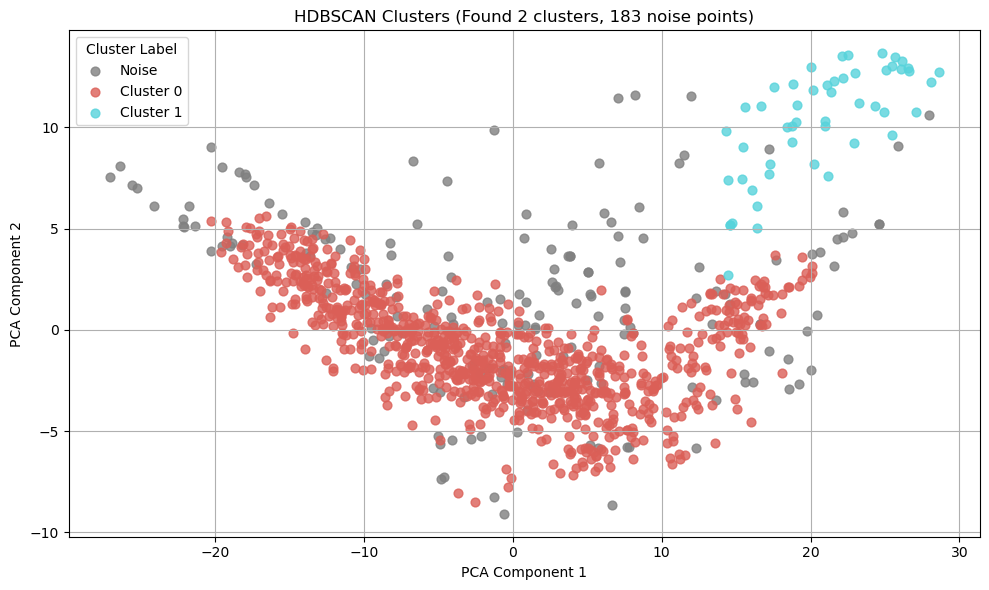

In [ ]:
# Reduce to 2D
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Get unique labels and palette
unique_labels = sorted(set(labels))
n_clusters = len([l for l in unique_labels if l != -1])
palette = sns.color_palette("hls", n_clusters)
color_map = {label: palette[i] for i, label in enumerate(l for l in unique_labels if l != -1)}
color_map[-1] = (0.5, 0.5, 0.5)  # noise = gray

# Plot each cluster with a label
plt.figure(figsize=(10, 6))
for label in unique_labels:
    mask = labels == label
    label_name = f"Cluster {label}" if label != -1 else "Noise"
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1],
                c=[color_map[label]],
                label=label_name,
                s=40, alpha=0.8)

# Add legend and labels
plt.legend(title="Cluster Label", loc="best")
plt.title(f"HDBSCAN Clusters (Found {n_clusters} clusters, {n_noise} noise points)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# add the labels to the dataframe
df["cluster"] = labels

df.to_csv("data_labeled/data_with_features_and_labels.csv", index=False)


In [ ]:
# get a dataframe with only the filename and cluster
df_cluster = df[['filename', 'cluster']]

In [33]:
df_cluster.head()

,filename,cluster
0,100303934_000_003.wav,0
1,100303934_003_006.wav,0
2,100303934_006_009.wav,0
3,100303934_009_012.wav,1
4,100971737_000_003.wav,0


In [40]:
# merge birdnet and cluster dataframes 
df_merged = df_birdnet.merge(df_cluster, left_on="File_name", right_on="filename", how="left")

In [ ]:
df_merged = df_merged.drop(columns=['filename','Scientific name'])

In [39]:
df_merged.to_csv("data_labeled/data_merged.csv", index=False)

## Load manually labelled dataset to obtain metrics, such as accuracy, precision, recall, F1 for each confidence level

Defining functions

In [3]:
# defining metrics for the analysis
def metrics(df):
    """
    Calculate precision, recall, and F1 score for the given dataframe.
    
    """
    # False Positives (FP)
    FP = len(df[df['Check'] == 0])

    # True Positives (TP)
    TP = len(df[df['Check'] == 1])
    
    # False Negatives (FN)
    FN = len(df[df['Check'] == 2])
    
    # True Negatives (TN)
    TN = len(df[df['Check'] == 3])

    # Accuracy
    accuracy = (TP + TN) / (TP + TN + FP + FN) 
    
    # Precision
    precision = TP / (TP + FP) 
    
    # Recall
    recall = TP / (TP + FN) 
    
    # F1 Score
    f1_score = 2 * (precision * recall) / (precision + recall)
    
    print(f"Accuracy: {round(accuracy, 3)}")
    print(f"Precision: {round(precision, 3)}")
    print(f"Recall: {round(recall, 3)}")
    print(f"F1 Score: {round(f1_score, 3)}")

In [4]:
def conf_matrix(df):
    """
    Generate a confusion matrix for the given dataframe.
    
    """
    y_true = df['True_label']
    y_pred = df['Predicted_label']
    
    # Generate confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    
    # Display the confusion matrix
    cm_display = ConfusionMatrixDisplay(confusion_matrix=cm)
    cm_display.plot()

    # print the confusion matrix values
    print("Confusion Matrix:")
    print(cm)

Loading manually labeled dataset

In [5]:
df_label = pd.read_excel('data_labeled/data_merged_and_labeled_20250422_full.xlsx')
df_label.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1373 entries, 0 to 1372
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   File_name    1373 non-null   object 
 1   Common name  1373 non-null   object 
 2   Buzz_Pranav  0 non-null      float64
 3   Call_Pranav  0 non-null      float64
 4   Buzz         1373 non-null   int64  
 5   Call         1373 non-null   int64  
 6   Confidence   1188 non-null   float64
 7   Cluster      1373 non-null   int64  
dtypes: float64(3), int64(3), object(2)
memory usage: 85.9+ KB


Preprocessing dataset

In [19]:
df_label['Confidence'] = df_label['Confidence'].fillna(0) # fill NaN values with 0, bc Birdnet exluded those files during the analysis

# add additional columns for futher analysis

df_label["Annotation_match"] = ((df_label['Call_Pranav'] == df_label['Call']) & 
                                 (df_label['Buzz_Pranav'] == df_label["Buzz"])).astype(int) # check if the label annotated by the researcher matches the domain expert's label

# define conditions
conditions = [
    (df_label['Common name'] == "Hume's Warbler") & ((df_label['Buzz'] == 0) & (df_label['Call'] == 0)),
    (df_label['Common name'] == "Hume's Warbler") & ((df_label['Buzz'] == 1) | (df_label['Call'] == 1)),
    (df_label['Common name'] != "Hume's Warbler") & ((df_label['Buzz'] == 1) | (df_label['Call'] == 1)),
    (df_label['Common name'] != "Hume's Warbler") & ((df_label['Buzz'] == 0) & (df_label['Call'] == 0))
]

# define corresponding values for the conditions
values = [0, 1, 2, 3] # where 0 = false positive, 1 = true positive, 2 = false negative, 3 = true negative

# Apply the conditions and assign the value to 'Check' column
df_label['Check'] = np.select(conditions, values, default=None) ## check if the label is correct, annotated by a researcher

# define conditions for domain expert
conditions_domain = [
    (df_label['Common name'] == "Hume's Warbler") & ((df_label['Buzz_Pranav'] == 0) & (df_label['Call_Pranav'] == 0)),
    (df_label['Common name'] == "Hume's Warbler") & ((df_label['Buzz_Pranav'] == 1) | (df_label['Call_Pranav'] == 1)),
    (df_label['Common name'] != "Hume's Warbler") & ((df_label['Buzz_Pranav'] == 1) | (df_label['Call_Pranav'] == 1)),
    (df_label['Common name'] != "Hume's Warbler") & ((df_label['Buzz_Pranav'] == 0) & (df_label['Call_Pranav'] == 0))
]

# Apply the conditions and assign the value to 'Check' column
df_label['Check_Pranav'] = np.select(conditions_domain, values, default=None) ## check if the label is correct, annotated by the domain expert


# add columns for the confusion matrix
df_label['True_label'] = ((df_label['Check'] == 1) | (df_label['Check'] == 2)).astype(int)
df_label['True_label_Pranav'] = ((df_label['Check_Pranav'] == 1) | (df_label['Check_Pranav'] == 2)).astype(int)
df_label['Predicted_label'] = (df_label['Common name'] == "Hume's Warbler").astype(int)

In [20]:
df_label.head(10)

,File_name,Common name,Buzz_Pranav,Call_Pranav,Buzz,Call,Confidence,Cluster,Annotation_match,Check,Check_Pranav,True_label,True_label_Pranav,Predicted_label
0,100303934_000_003.wav,Hume's Warbler,NaN,NaN,0,1,0.9588,0,0,1,None,1,0,1
1,100303934_003_006.wav,Hume's Warbler,NaN,NaN,0,1,0.9927,0,0,1,None,1,0,1
2,100303934_006_009.wav,Hume's Warbler,NaN,NaN,0,1,0.9865,0,0,1,None,1,0,1
3,100303934_009_012.wav,Hume's Warbler,NaN,NaN,0,1,0.9831,1,0,1,None,1,0,1
4,100971737_000_003.wav,Hume's Warbler,NaN,NaN,0,1,0.8851,0,0,1,None,1,0,1
5,100971737_003_006.wav,Hume's Warbler,NaN,NaN,0,1,0.2248,0,0,1,None,1,0,1
6,100971737_006_009.wav,No Data,NaN,NaN,0,0,0.0000,0,0,3,None,0,0,0
7,100971737_009_012.wav,Hume's Warbler,NaN,NaN,0,1,0.3209,-1,0,1,None,1,0,1
8,101454210_000_003.wav,Hume's Warbler,NaN,NaN,0,1,0.5942,0,0,1,None,1,0,1
9,101454210_000_003.wav,Hammond's Flycatcher,NaN,NaN,0,0,0.1378,0,0,3,None,0,0,0


In [21]:
metrics(df_label)

Accuracy: 0.913
Precision: 0.915
Recall: 0.929
F1 Score: 0.922


Confusion Matrix:
[[552  65]
 [ 54 702]]


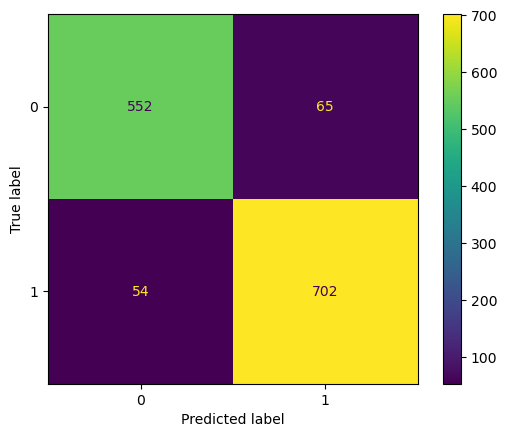

In [22]:
conf_matrix(df_label)

- True Negatives (TN) = 552: The Birdnet model correctly identified 552 snippets as negative.
- False Positives (FP) = 65: The Birdnet model incorrectly predicted 65 snippets as positive when they were actually negative. 
- False Negatives (FN) = 54: The Birdnet model incorrectly predicted 54 snippets as negative when they were actually positive. 
- True Positives (TP) = 702: The Birdnet model correctly identified 702 snippets as positive.

Exploring datasets with different confidence levels

In [23]:
df_02 = df_label[df_label['Confidence'] < 0.2]
df_04 = df_label[(df_label['Confidence'] >= 0.2) & (df_label['Confidence'] < 0.4)]
df_06 = df_label[(df_label['Confidence'] >= 0.4) & (df_label['Confidence'] < 0.6)]
df_08 = df_label[(df_label['Confidence'] >= 0.6) & (df_label['Confidence'] < 0.8)]
df_1 = df_label[df_label['Confidence'] >= 0.8]

In [24]:
print("Confidence < 0.2")
metrics(df_02)
print("_" * 28)
print("Confidence >= 0.2 and < 0.4")
metrics(df_04)
print("_" * 28)
print("Confidence >= 0.4 and < 0.6")
metrics(df_06)
print("_" * 28)
print("Confidence >= 0.6 and < 0.8")
metrics(df_08)
print("_" * 28)
print("Confidence >= 0.8")
metrics(df_1)
print("_" * 28)
print("Full dataset")
metrics(df_label)




Confidence < 0.2
Accuracy: 0.877
Precision: 0.5
Recall: 0.316
F1 Score: 0.387
____________________________
Confidence >= 0.2 and < 0.4
Accuracy: 0.845
Precision: 0.667
Recall: 0.78
F1 Score: 0.719
____________________________
Confidence >= 0.4 and < 0.6
Accuracy: 0.877
Precision: 0.841
Recall: 0.949
F1 Score: 0.892
____________________________
Confidence >= 0.6 and < 0.8
Accuracy: 0.869
Precision: 0.864
Recall: 0.972
F1 Score: 0.915
____________________________
Confidence >= 0.8
Accuracy: 0.974
Precision: 0.977
Recall: 0.996
F1 Score: 0.986
____________________________
Full dataset
Accuracy: 0.913
Precision: 0.915
Recall: 0.929
F1 Score: 0.922


Confidence < 0.2
Confusion Matrix:
[[388  18]
 [ 39  18]]
____________________________
Confidence >= 0.2 and < 0.4
Confusion Matrix:
[[104  16]
 [  9  32]]
____________________________
Confidence >= 0.4 and < 0.6
Confusion Matrix:
[[27  7]
 [ 2 37]]
____________________________
Confidence >= 0.6 and < 0.8
Confusion Matrix:
[[16 11]
 [ 2 70]]
____________________________
Confidence >= 0.8
Confusion Matrix:
[[ 17  13]
 [  2 545]]
____________________________
Full dataset
Confusion Matrix:
[[552  65]
 [ 54 702]]


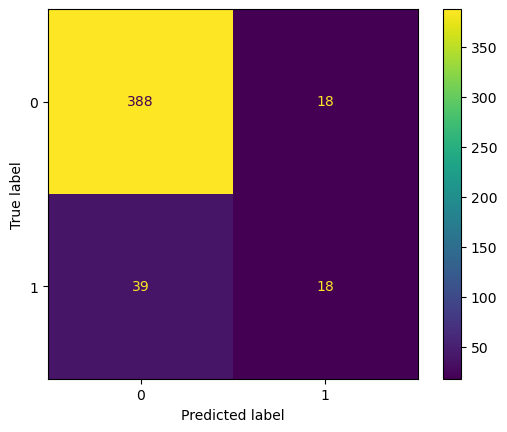

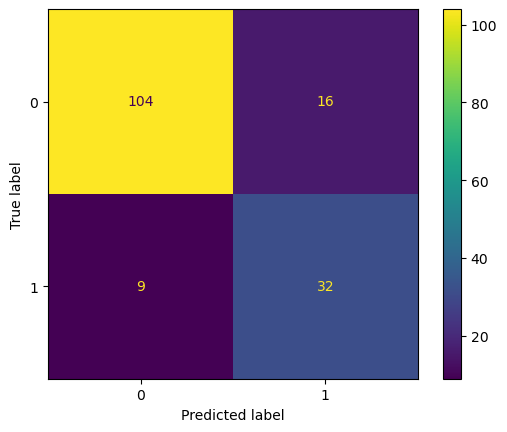

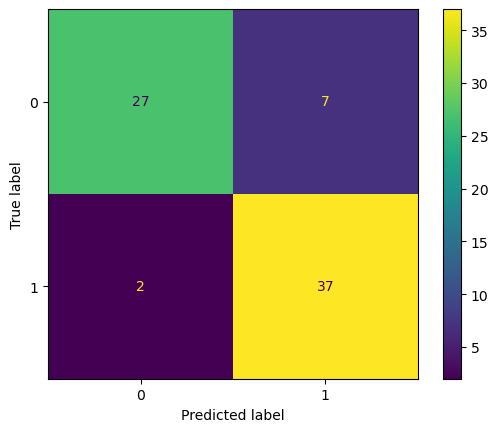

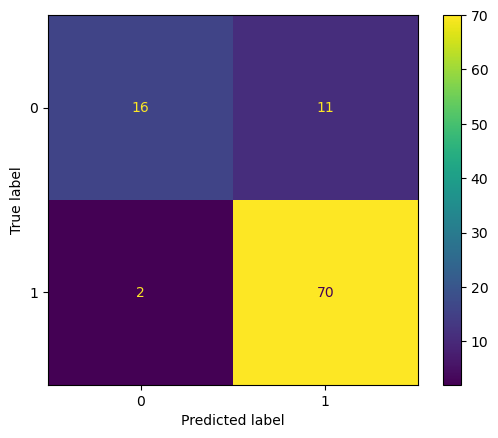

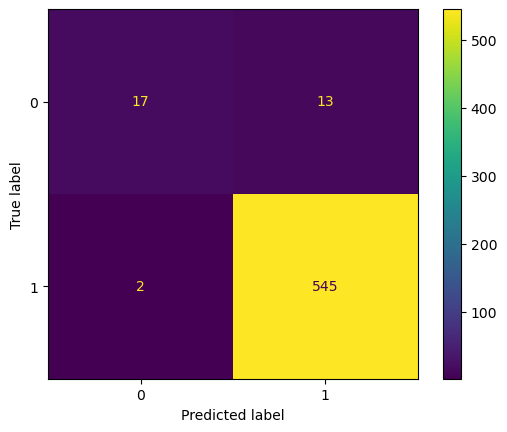

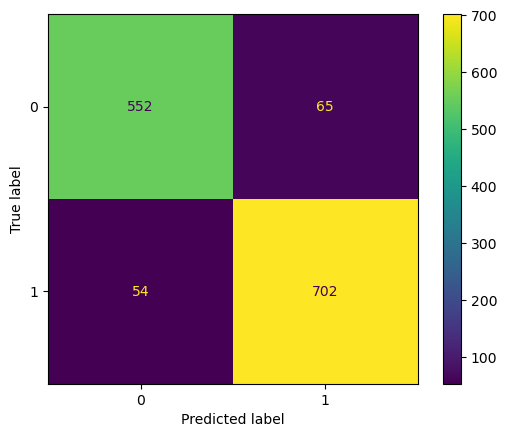

In [25]:
print("Confidence < 0.2")
conf_matrix(df_02)
print("_" * 28)
print("Confidence >= 0.2 and < 0.4")
conf_matrix(df_04)
print("_" * 28)
print("Confidence >= 0.4 and < 0.6")
conf_matrix(df_06)
print("_" * 28)
print("Confidence >= 0.6 and < 0.8")
conf_matrix(df_08)
print("_" * 28)
print("Confidence >= 0.8")
conf_matrix(df_1)
print("_" * 28)
print("Full dataset")
conf_matrix(df_label)

## Summary